#  Customer Churn Prediction – Complete ML Pipeline

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, roc_curve,
                              precision_score, recall_score, f1_score)
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
palette = ['#4C72B0', '#DD8452']
print("All libraries imported successfully!")


All libraries imported successfully!


In [3]:
df = pd.read_csv("C:\\Users\\yashj\\All Work\\All Assignment\\SL_assignment\\Predicting Customer Churn\\Churn_Modelling (1).csv")
print("Shape:", df.shape)
df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [6]:
df.describe().round(2)

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,5000.50,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,2886.90,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,1.00,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,2500.75,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,5000.50,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,7500.25,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,10000.00,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


In [7]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

C:\Users\yashj\AppData\Local\Temp\ipykernel_5728\2840800908.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df, ax=axes[0,0], palette='Set2')
C:\Users\yashj\AppData\Local\Temp\ipykernel_5728\2840800908.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=geo, x='Geography', y='Exited', ax=axes[0,1], palette='Blues')
C:\Users\yashj\AppData\Local\Temp\ipykernel_5728\2840800908.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gen, x='Gender', y='Exited', ax=axes[0,2], palette='pastel')


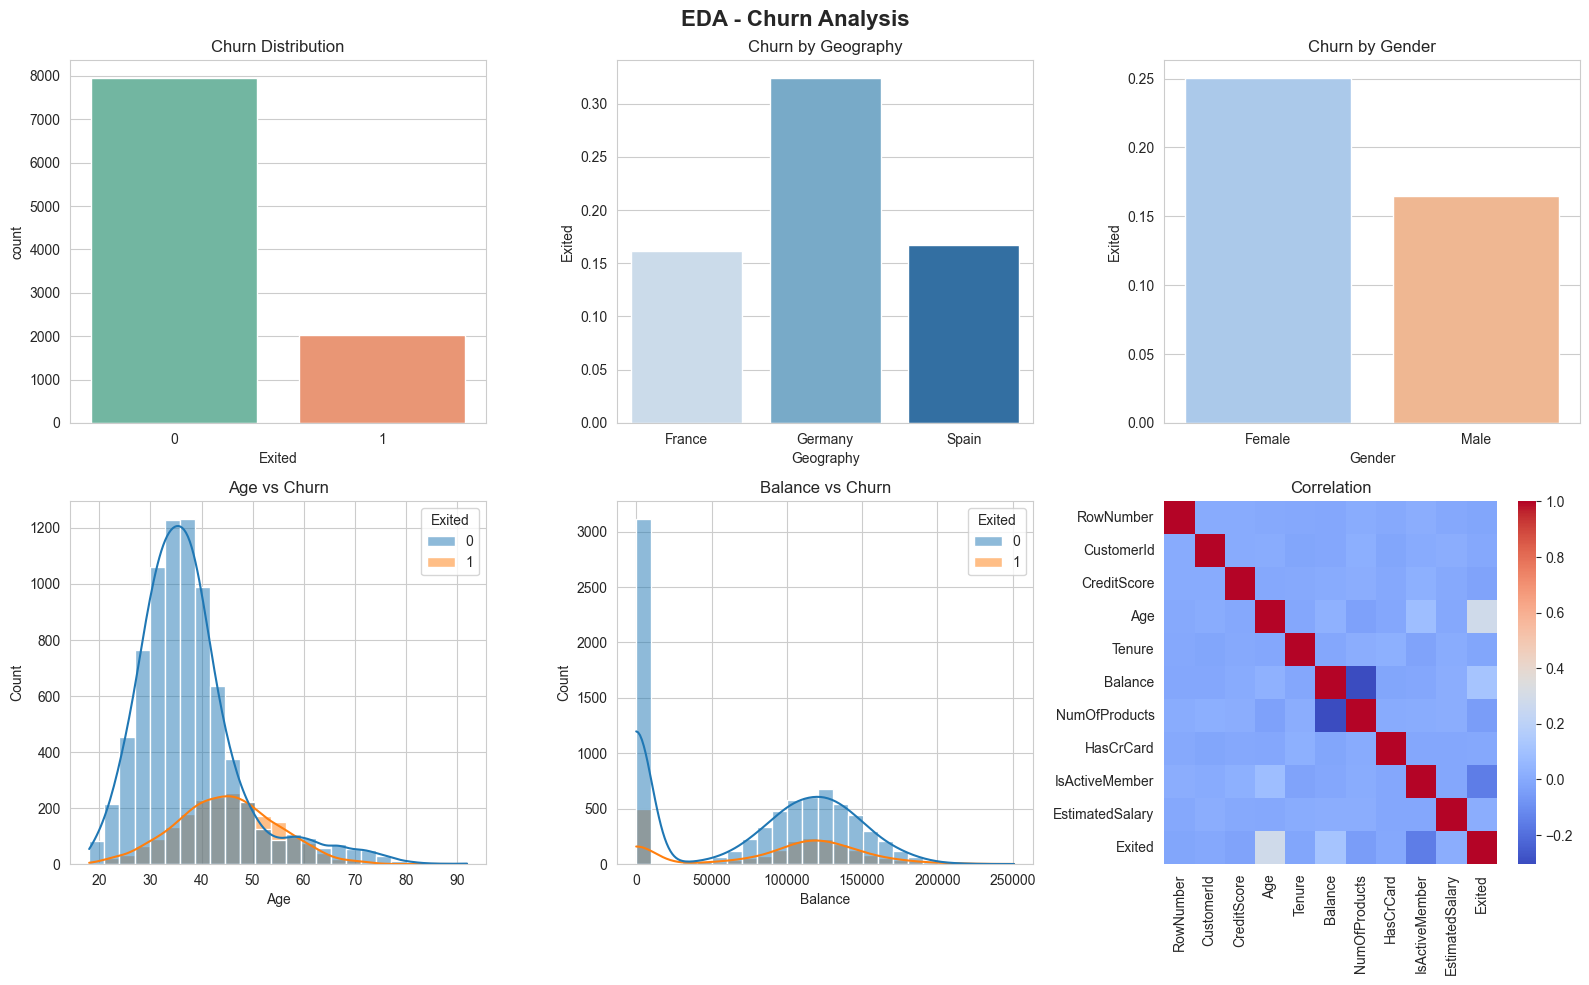

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("EDA - Churn Analysis", fontsize=16, fontweight="bold")

# 1. Target Distribution
sns.countplot(x='Exited', data=df, ax=axes[0,0], palette='Set2')
axes[0,0].set_title("Churn Distribution")

# 2. Geography vs Churn
geo = df.groupby('Geography')['Exited'].mean().reset_index()
sns.barplot(data=geo, x='Geography', y='Exited', ax=axes[0,1], palette='Blues')
axes[0,1].set_title("Churn by Geography")

# 3. Gender vs Churn
gen = df.groupby('Gender')['Exited'].mean().reset_index()
sns.barplot(data=gen, x='Gender', y='Exited', ax=axes[0,2], palette='pastel')
axes[0,2].set_title("Churn by Gender")

# 4. Age Distribution
sns.histplot(data=df, x='Age', hue='Exited', bins=25, kde=True, ax=axes[1,0])
axes[1,0].set_title("Age vs Churn")

# 5. Balance Distribution
sns.histplot(data=df, x='Balance', hue='Exited', bins=25, kde=True, ax=axes[1,1])
axes[1,1].set_title("Balance vs Churn")

# 6. Correlation Heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', annot=False, ax=axes[1,2])
axes[1,2].set_title("Correlation")

plt.tight_layout()
plt.show()

In [10]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

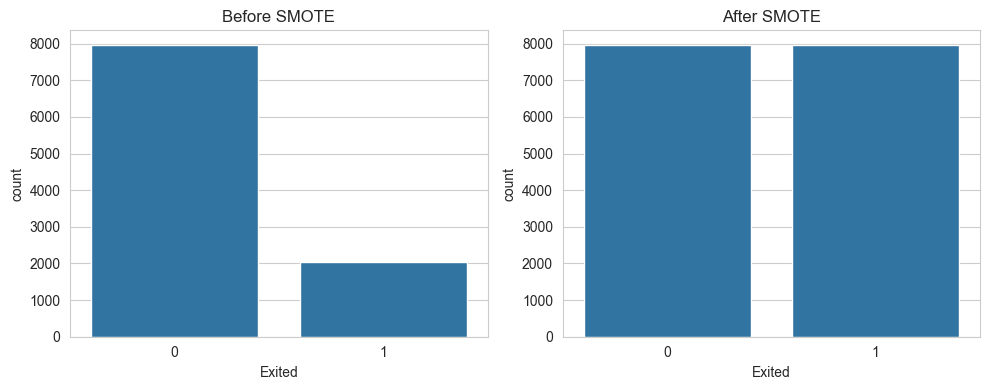

In [12]:
# Preprocessing
df_model = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

le = LabelEncoder()
df_model['Geography'] = le.fit_transform(df_model['Geography'])
df_model['Gender'] = le.fit_transform(df_model['Gender'])

X = df_model.drop('Exited', axis=1)
y = df_model['Exited']

# SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x=y, ax=axes[0])
axes[0].set_title("Before SMOTE")

sns.countplot(x=y_res, ax=axes[1])
axes[1].set_title("After SMOTE")

plt.tight_layout()
plt.show()

In [13]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (12740, 10)
Test shape : (3186, 10)


In [14]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    print("\nModel Evaluation:")
    print(classification_report(y_test, y_pred))

    return {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1 Score":  f1_score(y_test, y_pred)
    }

In [15]:
results = []

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

result = evaluate_model(lr, X_test, y_test)
results.append(result)


Model Evaluation:
              precision    recall  f1-score   support

           0       0.77      0.76      0.77      1593
           1       0.76      0.78      0.77      1593

    accuracy                           0.77      3186
   macro avg       0.77      0.77      0.77      3186
weighted avg       0.77      0.77      0.77      3186



In [16]:
nb = GaussianNB()
nb.fit(X_train, y_train)

results.append(evaluate_model(nb, X_test, y_test))


Model Evaluation:
              precision    recall  f1-score   support

           0       0.78      0.80      0.79      1593
           1       0.80      0.78      0.79      1593

    accuracy                           0.79      3186
   macro avg       0.79      0.79      0.79      3186
weighted avg       0.79      0.79      0.79      3186



In [17]:
k_scores = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    k_scores.append(f1_score(y_test, y_pred))

best_k = k_scores.index(max(k_scores)) + 1

print("Best K:", best_k)

Best K: 1


In [19]:
best_k = k_scores.index(max(k_scores)) + 1

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
results.append(evaluate_model(knn, X_test, y_test))


Model Evaluation:
              precision    recall  f1-score   support

           0       0.84      0.78      0.81      1593
           1       0.80      0.85      0.82      1593

    accuracy                           0.82      3186
   macro avg       0.82      0.82      0.81      3186
weighted avg       0.82      0.82      0.81      3186

